In [1]:
from pathlib import Path
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

year = 2025

ROOT_DIR = Path.cwd().parent.resolve()

processed_folder = (
    ROOT_DIR
    / "data"
    / "processed"
)

feature_matrix_file = (
    processed_folder
    / f"driver_feature_matrix_{year}.csv"
)

if not feature_matrix_file.exists():

    raise FileNotFoundError(
        f"Could not find "
        f"{feature_matrix_file}"
    )

feature_matrix = pd.read_csv(
    feature_matrix_file
)

print(
    f"Loaded "
    f"{len(feature_matrix)} "
    f"driver profiles"
)

feature_matrix.head()

Loaded 21 driver profiles


,Driver,RelativePace,PaceStdDev,FastestLapDelta,FullThrottleRatio,BrakeUsageRatio,GearChangeRate,AvgBrakeDistance,AvgEntrySpeed,AvgExitSpeed,AvgSpeedReduction,DegradationRate,PaceDropoff
0,ALB,1.002417,3.882050,1.411333,0.421794,0.216855,0.065049,78.255544,222.456871,129.421477,93.035394,-0.555945,-10.435787
1,ALO,1.003237,3.753785,1.817217,0.464311,0.203280,0.071081,75.208798,221.165666,130.706742,90.458924,-0.497511,-9.525572
2,ANT,0.999886,3.399411,1.430739,0.455688,0.222045,0.063773,78.813987,226.148132,131.221762,94.926370,-0.412716,-8.556817
3,BEA,1.004454,3.667849,1.859208,0.466087,0.216366,0.064023,78.429723,226.425495,133.081519,93.343976,-0.587055,-9.462333
4,BOR,1.007397,3.434591,1.881286,0.435715,0.229357,0.069240,79.084051,215.942974,124.039810,91.903164,-0.327658,-6.990013


In [2]:
drivers = feature_matrix[
    "Driver"
]

features = feature_matrix.drop(
    columns=["Driver"]
)

scaler = StandardScaler()

X = scaler.fit_transform(
    features
)

print(
    f"Scaled "
    f"{X.shape[1]} "
    f"features"
)

Scaled 12 features


In [3]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    X
)

driver_clusters = (
    feature_matrix[
        ["Driver"]
    ]
    .copy()
)

driver_clusters[
    "Cluster"
] = clusters

driver_clusters.sort_values(
    "Cluster"
)

c:\Users\VINAYAK SAXENA\anaconda3\envs\python_ds\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\VINAYAK SAXENA\anaconda3\envs\python_ds\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\VINAYAK SAXENA\anaconda3\envs\python_ds\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\VINAYAK SAXENA\anaconda3\envs\python_ds\Lib\subprocess.py",

,Driver,Cluster
1,ALO,0
4,BOR,0
5,COL,0
10,HUL,0
14,OCO,0
18,STR,0
6,DOO,1
13,NOR,2
15,PIA,2
20,VER,2


In [4]:
for cluster in sorted(
    driver_clusters[
        "Cluster"
    ].unique()
):

    print(
        "\n--------------------"
    )

    print(
        f"Cluster {cluster}"
    )

    members = driver_clusters[
        driver_clusters[
            "Cluster"
        ] == cluster
    ]

    print(
        members[
            "Driver"
        ].tolist()
    )


--------------------
Cluster 0
['ALO', 'BOR', 'COL', 'HUL', 'OCO', 'STR']

--------------------
Cluster 1
['DOO']

--------------------
Cluster 2
['LEC', 'NOR', 'PIA', 'RUS', 'VER']

--------------------
Cluster 3
['ALB', 'ANT', 'BEA', 'GAS', 'HAD', 'HAM', 'LAW', 'SAI', 'TSU']


In [5]:
cluster_profiles = (
    feature_matrix
    .copy()
)

cluster_profiles[
    "Cluster"
] = clusters

cluster_profiles.head()

,Driver,RelativePace,PaceStdDev,FastestLapDelta,FullThrottleRatio,BrakeUsageRatio,GearChangeRate,AvgBrakeDistance,AvgEntrySpeed,AvgExitSpeed,AvgSpeedReduction,DegradationRate,PaceDropoff,Cluster
0,ALB,1.002417,3.882050,1.411333,0.421794,0.216855,0.065049,78.255544,222.456871,129.421477,93.035394,-0.555945,-10.435787,3
1,ALO,1.003237,3.753785,1.817217,0.464311,0.203280,0.071081,75.208798,221.165666,130.706742,90.458924,-0.497511,-9.525572,0
2,ANT,0.999886,3.399411,1.430739,0.455688,0.222045,0.063773,78.813987,226.148132,131.221762,94.926370,-0.412716,-8.556817,3
3,BEA,1.004454,3.667849,1.859208,0.466087,0.216366,0.064023,78.429723,226.425495,133.081519,93.343976,-0.587055,-9.462333,3
4,BOR,1.007397,3.434591,1.881286,0.435715,0.229357,0.069240,79.084051,215.942974,124.039810,91.903164,-0.327658,-6.990013,0


In [6]:
cluster_summary = (
    cluster_profiles
    .groupby(
        "Cluster"
    )
    .mean(
        numeric_only=True
    )
)

cluster_summary

,RelativePace,PaceStdDev,FastestLapDelta,FullThrottleRatio,BrakeUsageRatio,GearChangeRate,AvgBrakeDistance,AvgEntrySpeed,AvgExitSpeed,AvgSpeedReduction,DegradationRate,PaceDropoff
Cluster,,,,,,,,,,,,
0,1.005877,3.512595,1.797557,0.456791,0.217553,0.065722,75.908539,218.853506,128.794223,90.059283,-0.437989,-7.861536
1,1.006093,3.228269,1.497250,0.345378,0.203266,0.051063,77.504652,204.275062,112.490889,91.784173,-0.168853,-3.940074
2,0.990423,3.274337,0.687480,0.470463,0.201216,0.064104,76.030151,224.966066,130.025679,94.940387,-0.582246,-10.052312
3,1.002605,3.659783,1.568353,0.452181,0.220569,0.061247,80.094152,223.797470,128.387738,95.409733,-0.515921,-9.279458


In [7]:
driver_clusters[
    "Cluster"
].value_counts()

Cluster
3    9
0    6
2    5
1    1
Name: count, dtype: int64

In [8]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X
)

pca_df = pd.DataFrame(
    {
        "PC1":
            X_pca[:, 0],
        "PC2":
            X_pca[:, 1],
        "Driver":
            drivers,
        "Cluster":
            clusters
    }
)

pca_df.head()

,PC1,PC2,Driver,Cluster
0,-0.431877,1.121983,ALB,3
1,-0.573085,0.820978,ALO,0
2,-0.333753,0.422439,ANT,3
3,-0.989688,1.638672,BEA,3
4,2.498137,0.784082,BOR,0


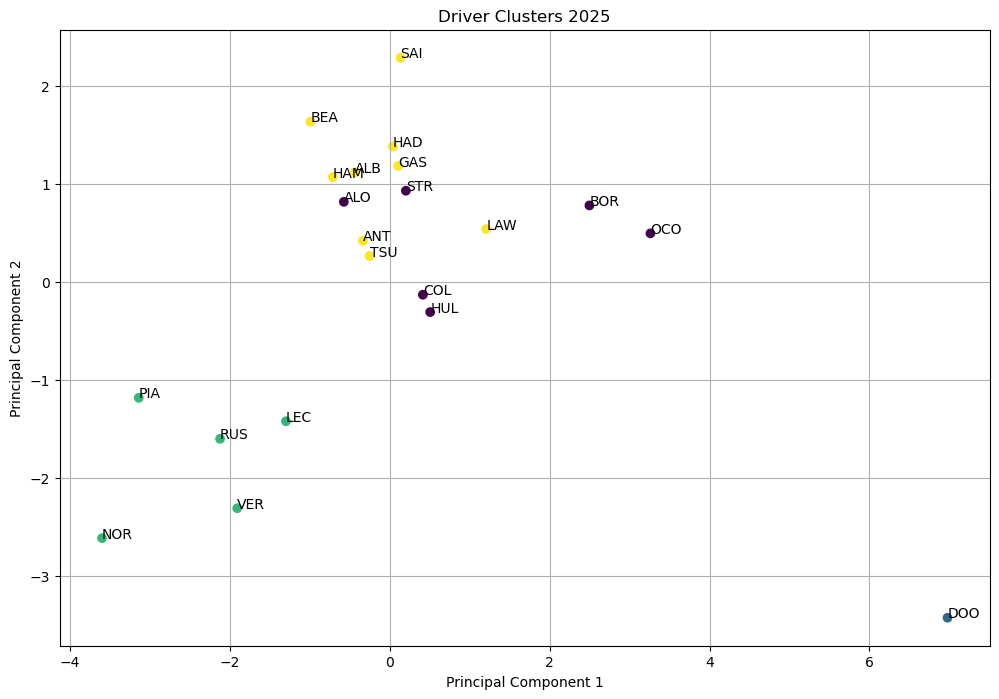

In [9]:
plt.figure(
    figsize=(12, 8)
)

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"]
)

for _, row in pca_df.iterrows():

    plt.annotate(
        row["Driver"],
        (
            row["PC1"],
            row["PC2"]
        )
    )

plt.title(
    f"Driver Clusters {year}"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.grid()

plt.show()

In [10]:
driver_clusters.sort_values("Cluster")

,Driver,Cluster
1,ALO,0
4,BOR,0
5,COL,0
10,HUL,0
14,OCO,0
18,STR,0
6,DOO,1
13,NOR,2
15,PIA,2
20,VER,2
